# Macro-based regime detection

**Chapter 1 · §1.4 Keeping up with changing market regimes**

**Docker image**: `ml4t`

`factor_regimes` estimated regimes from what the factors themselves earned. This notebook
asks whether the same partition can be recovered from outside the market, using
macroeconomic series published by the Federal Reserve Bank of St. Louis through its FRED
database: unemployment, the policy rate, the shape of the yield curve and inflation.

The appeal of macro inputs is that they are not returns. A regime estimated from returns
is at risk of restating the volatility it was fitted on; one estimated from the labour
market and the rate environment is a statement about conditions, which can then be
checked against what the equity market did. That check is the second half of this
notebook, and it is what separates a regime model that has found something from one that
has partitioned the calendar.

## Learning objectives

By the end of this notebook you will be able to:

- Turn irregularly published economic series into an aligned monthly panel without
  letting a later release inform an earlier month.
- Explain why a series that trends has to enter a clustering as a rate of change rather
  than as a level, and recognise the failure that follows from ignoring it.
- Attach economic names to unnamed clusters through a stated rule, and say what the rule
  assumes.
- Check estimated regimes against realized equity volatility and drawdown - evidence the
  clustering never saw - and say which half of that check passed.
- Judge a clustering by whether it recovers recurring conditions rather than by its
  separation score, and show why the two can point in opposite directions.
- Measure how much of a partition is left after a different random start or a slightly
  shorter sample, and report that beside the result rather than instead of it.

## Book reference

Chapter 1, Section 1.4, "Keeping up with changing market regimes". Figure 1.6 in the
chapter is the regime-and-volatility panel drawn below.

## Prerequisites

- `factor_regimes`, which introduces Gaussian mixture models, the silhouette score, and
  why a model fitted on the whole sample describes rather than predicts.
- The FRED panel, which `load_macro` reads. It needs a `FRED_API_KEY` and one run of
  `uv run python data/macro/download.py`; `data/macro/README.md` covers both.
- Daily S&P 500 index closes, which `load_sp500_index` reads. This one ships with the
  repository and needs no download.

## A caveat that applies to every number below

FRED serves the latest revision of each series. Unemployment, industrial production and
the price indices are all restated after their first publication, sometimes substantially,
so the value this notebook reads for a month in 2008 is not the value anyone could see in
2008. That is acceptable here because the labels are descriptive and nothing acts on them.
A strategy would have to read `load_macro_initial_release`, which serves the value as it
stood at each date, and would also have to wait out the publication lag - the
unemployment rate for a month is released in the first days of the next one.

# 以總體經濟為基礎的市場狀態偵測

**第 1 章 · §1.4 跟上不斷變化的市場狀態**

**Docker 映像檔**:`ml4t`

`factor_regimes` 是從因子本身賺到的報酬來估計市場狀態。本筆記本要問的是:能否從市場之外還原出同樣的分割,所用的是聖路易聯邦準備銀行透過其 FRED 資料庫發布的總體經濟序列:失業率、政策利率、殖利率曲線的形狀,以及通貨膨脹。

總體經濟輸入的吸引力在於它們不是報酬。從報酬估計出來的市場狀態,有可能只是把它所配適的波動度換個說法重述一遍;而從勞動市場與利率環境估計出來的市場狀態,是對經濟情勢的陳述,接著可以拿股票市場實際的表現來檢驗。這項檢驗是本筆記本的後半部,也是區分「真的找到了什麼的狀態模型」與「只是把日曆切開的狀態模型」的關鍵。

## 學習目標

讀完本筆記本後,你將能夠:

- 把發布時間不規則的經濟序列轉成對齊的月頻 panel,而不讓較晚發布的資料影響較早的月份。
- 解釋為什麼帶有趨勢的序列必須以變動率而非水準值進入分群,並辨認出忽略這一點所導致的失敗。
- 透過一條明確陳述的規則為未命名的群集冠上經濟意義的名稱,並說明這條規則做了哪些假設。
- 用已實現的股票波動度與回撤——分群過程從未看過的證據——來檢驗估計出來的市場狀態,並說明這項檢驗的哪一半通過了。
- 以「是否還原出反覆出現的情勢」而非分離度分數來評判一個分群結果,並說明為什麼這兩者可能指向相反的方向。
- 衡量在換一個隨機起點或把樣本稍微縮短之後,一個分割還剩下多少,並把這個結果放在主要結果旁邊一併報告,而不是用它取代主要結果。

## 書籍對照

第 1 章第 1.4 節「跟上不斷變化的市場狀態」。該章的圖 1.6 就是下面繪製的市場狀態與波動度圖組。

## 先備知識

- `factor_regimes`,其中介紹了高斯混合模型、輪廓係數,以及為什麼用全樣本配適的模型是在描述而非預測。
- FRED panel,由 `load_macro` 讀取。它需要一組 `FRED_API_KEY`,並執行一次 `uv run python data/macro/download.py`;兩者在 `data/macro/README.md` 都有說明。
- S&P 500 指數的每日收盤價,由 `load_sp500_index` 讀取。這份資料隨儲存庫一起提供,不需要下載。

## 適用於以下每一個數字的但書

FRED 提供的是每個序列最新修訂後的版本。失業率、工業生產與各種物價指數在初次發布後都會重新修訂,有時幅度相當大,所以本筆記本讀到的 2008 年某個月的數值,並不是任何人在 2008 年當時看得到的數值。這在這裡是可以接受的,因為這些標籤是描述性的,沒有任何東西據以行動。如果是策略,就必須讀取 `load_macro_initial_release`,它提供的是每個時點當時的數值;而且還必須等過發布的時間落差——某個月的失業率是在下個月的頭幾天才公布的。

## Setup

## 環境設定

In [4]:
"""Macro-based regime detection - clustering FRED indicators and validating against the S&P 500."""

from __future__ import annotations

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, scale

import utils.style as style
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from data import load_macro, load_macro_metadata, load_sp500_index

COLORS = style.COLORS

In [5]:
# Production defaults (Papermill overrides these when the test suite runs the notebook)
SEED = 42

### Settings, and what each one decides

`SEED` fixes every estimator's random start, which is what makes the cluster numbering
and the figures reproduce.

`N_REGIMES` is the number of clusters fitted throughout. Four is taken from the Two Sigma
study this notebook follows, which reports four regimes over an eighteen-factor panel. It
is a choice, not a result: `factor_regimes` shows how the model-selection criteria are
compared when the count is being decided rather than inherited.

`PANEL_START` is the first month the panel is allowed to contain. The FRED file begins in
2000, and the series used here are all quoted from that point, so the bound is set two
years later for the same reason a rolling statistic drops its warm-up: the year-over-year
inflation rate needs twelve prior months before it exists.

`MAX_MISSING_SHARE` is how much of a series may be unquoted before it is dropped from the
extended panel. `MIN_COPHENETIC` is the level above which a dendrogram is usually taken to
summarise its distance matrix faithfully; it is a convention, quoted here so the number
the notebook computes has something to be read against.

### 各項設定,以及每一項決定了什麼

`SEED` 固定了每個估計器的隨機起點,這樣群集編號與圖表才能重現。

`N_REGIMES` 是全篇配適所用的群集數。「四」取自本筆記本所依循的 Two Sigma 研究,該研究在一個十八因子的 panel 上回報了四個市場狀態。這是一項選擇,不是一個結果:`factor_regimes` 示範了當群集數是要被決定而非沿用時,如何比較各個模型選擇準則。

`PANEL_START` 是 panel 允許包含的第一個月。FRED 的檔案從 2000 年開始,而這裡使用的序列從那時起都有報價,所以這個界限設在兩年之後,理由和滾動統計量會捨棄暖身期一樣:年增率形式的通膨率需要先有十二個月的資料才能算得出來。

`MAX_MISSING_SHARE` 是一個序列在被從擴充 panel 中剔除之前,允許沒有報價的比例上限。`MIN_COPHENETIC` 是一個門檻,高於它時通常就認為樹狀圖(dendrogram)忠實地概括了它的距離矩陣;這是一項慣例,在這裡引用是為了讓筆記本算出來的數字有個對照的基準。

In [6]:
N_REGIMES = 4
PANEL_START = pl.datetime(2002, 1, 1)
MAX_MISSING_SHARE = 0.5
MIN_COPHENETIC = 0.7
MONTHS_PER_YEAR = 12
ROLLING_VOL_MONTHS = 12
DATE_COL = "timestamp"

OUTPUT_DIR = get_output_dir(1, "macro_regimes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_global_seeds(SEED)

## The FRED panel

The loader returns one wide frame with a daily date index and one column per series.
Series that are not published daily carry their most recent value forward, so the file has
no gaps to interpolate and the frequency a series was actually observed at has to be read
from its metadata rather than from the column.

## FRED panel

載入器回傳一個寬格式的資料表,以每日日期為索引,每個序列一欄。不是每日發布的序列會把最近一次的數值向前延續,所以檔案中沒有需要內插的缺口;而一個序列實際被觀測的頻率,必須從它的中繼資料(metadata)讀取,而不是從欄位本身看出來。

In [7]:
macro_raw = load_macro()
if macro_raw[DATE_COL].dtype == pl.Date:
    macro_raw = macro_raw.with_columns(pl.col(DATE_COL).cast(pl.Datetime))

print(f"FRED panel: {macro_raw.height} rows, {macro_raw.width - 1} series")
print(f"Covering {macro_raw[DATE_COL].min():%Y-%m-%d} to {macro_raw[DATE_COL].max():%Y-%m-%d}")

FRED panel: 9497 rows, 25 series
Covering 2000-01-01 to 2025-12-31


### What the panel holds

The metadata companion says what each column is, how often the source publishes it, and
whether it is an observed series or one this repository derives from others. Both facts
matter downstream: a quarterly series entering a monthly clustering repeats each value
three times, and a derived column can duplicate a series that is already in the panel
under its own name.

### panel 裡有什麼

搭配的中繼資料說明了每一欄是什麼、來源多久發布一次,以及它是實際觀測到的序列,還是本儲存庫從其他序列衍生出來的。這兩件事對後續都很重要:一個季頻序列進入月頻分群時,每個數值會重複三次;而一個衍生欄位可能和 panel 中已經以自己的名稱存在的序列重複。

In [8]:
metadata = load_macro_metadata().to_pandas().set_index("series")

# Reindex rather than select: the metadata file is maintained beside the data file and can
# fall behind it, and a column it does not describe should appear in this table saying so
# rather than stopping the notebook or vanishing from it.
inventory = (
    metadata.reindex([c for c in macro_raw.columns if c != DATE_COL])[
        ["description", "native_frequency", "formula"]
    ]
    .rename(
        columns={
            "description": "Series",
            "native_frequency": "Published",
            "formula": "Derived as",
        }
    )
    .fillna({"Series": "not described in the metadata file", "Published": "unknown"})
)
inventory["Derived as"] = inventory["Derived as"].fillna("-")
inventory.index.name = "Column"
inventory

,Series,Published,Derived as
Column,,,
dff,Fed Funds Rate,daily,-
dgs1,1-Year Treasury Constant Maturity,daily,-
dgs2,2-Year Treasury Constant Maturity,daily,-
dgs3,3-Year Treasury Constant Maturity,daily,-
dgs5,5-Year Treasury Constant Maturity,daily,-
dgs7,7-Year Treasury Constant Maturity,daily,-
dgs10,10-Year Treasury Constant Maturity,daily,-
dgs20,20-Year Treasury Constant Maturity,daily,-
dgs30,30-Year Treasury Constant Maturity,daily,-


## Four indicators that describe conditions

The core model uses four series, each standing for one thing a reader can name:

- **UNRATE**, the unemployment rate, for the state of the labour market.
- **DFF**, the effective federal funds rate, for the stance of monetary policy.
- **T10Y2Y**, the ten-year Treasury yield minus the two-year, for the shape of the yield
  curve. A negative value means short-dated debt yields more than long-dated debt, an
  inversion that has preceded most post-war US recessions.
- **CPIAUCSL**, the consumer price index, for inflation - entered as a rate of change,
  for the reason given below.

Four is few enough that every cluster can be described in a sentence, which is the point
of a regime label. The extended panel later in the notebook is the counter-experiment.

## 描述經濟情勢的四個指標

核心模型使用四個序列,每一個都代表一件讀者叫得出名字的事:

- **UNRATE**,失業率,代表勞動市場的狀況。
- **DFF**,有效聯邦基金利率,代表貨幣政策的立場。
- **T10Y2Y**,十年期公債殖利率減去兩年期殖利率,代表殖利率曲線的形狀。負值表示短天期債券的殖利率高於長天期債券,也就是所謂的倒掛,戰後美國大多數的經濟衰退之前都出現過這種現象。
- **CPIAUCSL**,消費者物價指數,代表通貨膨脹——以變動率的形式進入模型,理由見下文。

四個夠少,少到每個群集都能用一句話描述,而這正是市場狀態標籤的意義所在。筆記本稍後的擴充 panel 則是對照實驗。

In [9]:
CORE_SERIES = ["unrate", "dff", "t10y2y", "cpiaucsl"]

missing = [c for c in CORE_SERIES if c not in macro_raw.columns]
if missing:
    raise ValueError(
        f"The FRED panel is missing {missing}, which the core model is built on. "
        "Re-run data/macro/download.py; data/macro/README.md lists what it fetches."
    )

### From daily rows to a monthly panel

`group_by_dynamic` cuts the daily frame into calendar months and `last()` takes the final
observation inside each. Labelling each window by its right edge is what keeps the panel
honest: the window covering January is stamped 1 February, so the row can only contain
observations from January and nothing dated later reaches it.

That stamp is then stepped back a day, onto the last day of the month the row actually
describes. Without it every date in the notebook is a month late - the row holding
April's unemployment rate reads as May - and a figure axis, a printed date and the arrays
handed to the book build would all inherit the error.

### 從每日資料列到月頻 panel

`group_by_dynamic` 把每日資料表切成一個個日曆月,`last()` 則取出每個月內的最後一筆觀測值。以右邊界來標記每個視窗,是讓這個 panel 保持誠實的關鍵:涵蓋一月的視窗被標上 2 月 1 日,所以這一列只可能包含一月的觀測值,任何日期更晚的資料都進不來。

接著把這個時間戳記往回退一天,落在該列實際描述的那個月的最後一天。不這麼做的話,筆記本裡的每個日期都會晚一個月——存放四月失業率的那一列會被讀成五月——而圖表的座標軸、印出來的日期,以及交給書籍建置流程的陣列,全都會承襲這個錯誤。

In [10]:
def to_monthly(frame: pl.DataFrame, columns: list[str]) -> pl.DataFrame:
    """Last observation of each calendar month, stamped on the month it describes."""
    return (
        frame.select([DATE_COL, *columns])
        .sort(DATE_COL)
        .group_by_dynamic(DATE_COL, every="1mo", label="right")
        .agg([pl.col(c).last() for c in columns])
        .with_columns(pl.col(DATE_COL).dt.offset_by("-1d"))
    )

In [11]:
macro_monthly = (
    to_monthly(macro_raw, CORE_SERIES)
    .drop_nulls(subset=CORE_SERIES)
    .filter(pl.col(DATE_COL) >= PANEL_START)
)

print(f"Monthly rows: {macro_monthly.height}")
print(f"Covering {macro_monthly[DATE_COL].min():%Y-%m} to {macro_monthly[DATE_COL].max():%Y-%m}")

Monthly rows: 288
Covering 2002-01 to 2025-12


### Why the price index enters as a rate, not a level

The consumer price index rises almost every month of the sample. Clustering on the level
would put every early month in one cluster and every late month in another, because that
is the largest source of variance in the column, and the resulting partition would be a
statement about the calendar rather than about inflation. The year-over-year percentage
change removes the trend and leaves the quantity a reader means by inflation: how much
prices rose over the past twelve months. Taking it costs the first twelve months of the
panel, which is why the panel starts a year after `PANEL_START`.

The other three series are already rates and need no such treatment. All four are then
standardized. They share a unit - percentage points - but not a range: unemployment moves
over several points across a cycle while the yield spread moves over a fraction of one, so
without standardizing, the distances would be mostly unemployment.

### 為什麼物價指數要以變動率而非水準值進入模型

消費者物價指數在樣本期間幾乎每個月都在上升。如果對水準值做分群,就會把所有早期的月份放進一個群集、所有晚期的月份放進另一個群集,因為那是該欄位最大的變異來源,而得到的分割將是關於日曆的陳述,而不是關於通膨的陳述。年增率(year-over-year 百分比變動)移除了趨勢,留下讀者所說的通膨的那個量:過去十二個月物價上漲了多少。計算它要犧牲 panel 最前面的十二個月,這就是為什麼 panel 在 `PANEL_START` 的一年之後才開始。

其他三個序列本來就是比率,不需要這樣處理。接著四個序列都做標準化。它們的單位相同——百分點——但範圍不同:失業率在一個景氣循環中會變動好幾個百分點,而殖利率利差的變動幅度還不到一個百分點,所以如果不標準化,距離大部分就只是失業率。

In [12]:
macro_df = macro_monthly.select(CORE_SERIES).to_pandas()
macro_df.index = pd.DatetimeIndex(macro_monthly[DATE_COL].to_pandas())
macro_df["cpi_yoy"] = macro_df["cpiaucsl"].pct_change(MONTHS_PER_YEAR) * 100
macro_df = macro_df.drop(columns=["cpiaucsl"]).dropna()

macro_scaled = StandardScaler().fit_transform(macro_df)

PANEL_FIRST_YEAR = macro_df.index.min().year
PANEL_LAST_YEAR = macro_df.index.max().year
print(f"Clustering panel: {len(macro_df)} months, {PANEL_FIRST_YEAR} to {PANEL_LAST_YEAR}")

Clustering panel: 276 months, 2003 to 2025


### The four series before anything is fitted

The table reports each series in its own units over the clustering panel. Read each
quartile spread against its own minimum and maximum: the policy rate covers the whole
distance from the zero bound to the peak of a tightening cycle, while the unemployment
rate sits tight around its median and then makes one excursion far outside it. Those
shapes are what the mixture is about to partition, and the second one is why a cluster
ends up holding very few months.

### 尚未配適任何模型之前的四個序列

下表以各序列自己的單位,列出它們在分群 panel 上的統計量。請把每個序列的四分位距對照它自己的最小值與最大值來讀:政策利率涵蓋了從零利率下限到緊縮循環高峰的整段距離,而失業率則緊貼著中位數,然後有一次遠遠偏離出去。這些形狀就是混合模型即將分割的對象,而第二種形狀正是為什麼最後會有一個群集只包含極少數月份。

In [13]:
UNITS = {
    "unrate": "Unemployment rate (%)",
    "dff": "Fed funds rate (%)",
    "t10y2y": "10Y minus 2Y Treasury (percentage points)",
    "cpi_yoy": "CPI, change over 12 months (%)",
}
macro_df.rename(columns=UNITS).describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Unemployment rate (%),276.00,5.75,2.02,3.40,4.20,5.00,6.70,14.80
Fed funds rate (%),276.00,1.76,1.91,0.04,0.10,1.04,3.12,5.41
10Y minus 2Y Treasury (percentage points),276.00,1.06,0.97,-1.06,0.24,1.00,1.88,2.84
"CPI, change over 12 months (%)",276.00,2.58,1.81,-1.96,1.63,2.32,3.25,8.98


## Fit the mixture

The same estimator as `factor_regimes`: a full-covariance Gaussian mixture, restarted ten
times from different initializations, keeping the fit with the highest likelihood.

## 配適混合模型

估計器與 `factor_regimes` 相同:完整共變異數的高斯混合模型,從不同的初始值重新啟動十次,保留概似值最高的那次配適。

In [14]:
gmm_core = GaussianMixture(
    n_components=N_REGIMES,
    covariance_type="full",
    random_state=SEED,
    n_init=10,
    reg_covar=1e-6,
)
gmm_core.fit(macro_scaled)
core_labels = gmm_core.predict(macro_scaled)
core_probabilities = gmm_core.predict_proba(macro_scaled)
core_silhouette = float(silhouette_score(macro_scaled, core_labels))

print(f"Core model silhouette: {core_silhouette:.3f}")

Core model silhouette: 0.327


### What the clusters contain

The mixture returns numbers. The table below is what those numbers mean: the average of
each indicator over the months assigned to each cluster, in the original units.

### 各群集包含什麼

混合模型回傳的是編號。下表說明這些編號的意義:每個指標在被指派到各群集的月份上的平均值,以原始單位表示。

In [15]:
cluster_means = macro_df.groupby(core_labels).mean()
cluster_means.index.name = "Cluster"
cluster_means.rename(columns=UNITS).style.format("{:.2f}")

,Unemployment rate (%),Fed funds rate (%),10Y minus 2Y Treasury (percentage points),"CPI, change over 12 months (%)"
Cluster,,,,
0,4.34,4.62,0.02,3.28
1,7.85,0.11,1.84,1.47
2,4.19,1.30,0.61,1.91
3,5.18,1.43,1.46,4.39


### Naming the clusters

A cluster number is not a regime name, and the names have to come from somewhere the model
cannot supply. The rule below reads each cluster's average indicators and applies the first
description that fits, in a fixed order. Both the ordering and the thresholds are
judgements about the post-2002 US economy, chosen so each name means what a reader expects:
unemployment above ten percent is a crisis whatever the rate environment; high unemployment
with the policy rate at the floor is the aftermath rather than the crisis itself; a high
policy rate with a flat curve is a tightening cycle.

Not every branch has to fire. Which names come out depends on which clusters the mixture
found, and the table below is where to see what this fit produced rather than what the rule
can produce.

The rule is written in one place so that it can be argued with. A different reader would set
different thresholds and get different names over the same partition, and that is the honest
situation: the clustering is estimated, the naming is asserted.

### 為群集命名

群集編號不是市場狀態的名稱,而名稱必須來自某個模型無法提供的地方。下面的規則讀取每個群集的平均指標值,依固定的順序套用第一個符合的描述。順序與門檻兩者都是對 2002 年之後美國經濟所做的判斷,選定的方式是讓每個名稱的意思符合讀者的預期:失業率超過百分之十,不論利率環境如何都是危機;高失業率加上政策利率貼在下限,是危機的餘波而非危機本身;高政策利率加上平坦的曲線,則是緊縮循環。

不是每個分支都一定會被觸發。會出現哪些名稱,取決於混合模型找到了哪些群集;要看的是這次配適實際產生了什麼,而不是這條規則可能產生什麼,答案就在下表。

這條規則集中寫在一個地方,就是為了讓人可以對它提出質疑。不同的讀者會設定不同的門檻,並在同一個分割上得到不同的名稱,而這正是實情:分群是估計出來的,命名則是主張出來的。

In [16]:
def name_clusters(means: pd.DataFrame) -> dict[int, str]:
    """Attach an economic description to each cluster from its average indicators."""
    names: dict[int, str] = {}
    for cluster in means.index:
        row = means.loc[cluster]
        if row["unrate"] > 10:
            names[cluster] = "Crisis"
        elif row["unrate"] > 6 and row["dff"] < 0.5:
            names[cluster] = "Recovery"
        elif row["dff"] > 3 and row["t10y2y"] < 0.5:
            names[cluster] = "Tightening"
        elif row["cpi_yoy"] > 4:
            names[cluster] = "Inflation"
        elif row["unrate"] < 5 and row["dff"] < 2:
            names[cluster] = "Expansion"
        else:
            names[cluster] = "Transition"
    return names

In [17]:
cluster_names = name_clusters(cluster_means)
if len(set(cluster_names.values())) != len(cluster_names):
    raise ValueError(f"Two clusters received the same name: {cluster_names}")

regime_name = pd.Series(
    [cluster_names[label] for label in core_labels], index=macro_df.index, name="regime"
)
ordered_names = [cluster_names[cluster] for cluster in cluster_means.index]
pd.DataFrame(
    {"Name": ordered_names, "Months": regime_name.value_counts()[ordered_names].to_numpy()},
    index=cluster_means.index,
)

,Name,Months
Cluster,,
0,Tightening,72
1,Recovery,100
2,Expansion,51
3,Inflation,53


## Do the regimes correspond to anything the market did?

The clustering has seen no market data at all. If the four groups are picking up real
conditions rather than an arbitrary carve-up of a four-dimensional cloud, then equity
returns should behave differently inside them, and the difference should be in the
direction economic reasoning predicts.

The S&P 500 daily series is resampled to month-end closes and joined to the macro panel on
the date. Both are now stamped on the last day of the month they describe, so the join is
exact and each macro row meets the close of the month whose conditions it reports.

## 這些市場狀態對應到市場實際發生的任何事嗎?

分群過程完全沒有看過任何市場資料。如果這四個群組捕捉到的是真實的經濟情勢,而不是對一團四維點雲的任意切割,那麼股票報酬在各群組內的表現就應該有所不同,而且差異的方向應該符合經濟推理的預測。

S&P 500 的每日序列被重新取樣為月底收盤價,並依日期與總經 panel 合併。兩者現在都標記在所描述月份的最後一天,所以合併是精確的,每一列總經資料都對上它所報告之經濟情勢那個月的收盤價。

In [18]:
sp500 = load_sp500_index().to_pandas()
sp500[DATE_COL] = pd.to_datetime(sp500[DATE_COL])
sp500 = sp500.set_index(DATE_COL)

sp500_monthly = sp500["close"].resample("ME").last().to_frame()
sp500_monthly["returns"] = sp500_monthly["close"].pct_change()

aligned = sp500_monthly.reindex(macro_df.index)
if aligned["close"].isna().any():
    raise ValueError("A macro month found no S&P 500 close on the same month-end")

print(f"Aligned {len(aligned)} months of S&P 500 closes to the macro panel")

Aligned 276 months of S&P 500 closes to the macro panel


### Two statistics per regime, and what each one is

**Annualized volatility** is the standard deviation of the monthly returns of the months
assigned to a regime, multiplied by the square root of twelve. It describes the months in
that regime and nothing else.

**Maximum drawdown** is taken differently, and the difference matters. The running peak is
computed over the whole index, in calendar order, and each month's decline from that peak
is measured; the number reported for a regime is the deepest such decline observed in one
of its months. It is therefore the worst point of the index reached while conditions were
in that regime, not the drawdown of a portfolio held only during it. Where the deepest
reading lands is therefore a fact about which regime was in force when the index bottomed,
and that is the fact worth reading off the table.

### 每個市場狀態的兩個統計量,以及它們各自是什麼

**年化波動度**是被指派到某個市場狀態的月份的月報酬標準差,乘以十二的平方根。它描述的是該狀態中的月份,僅此而已。

**最大回撤**的算法不同,而這個差別很重要。滾動高點是在整個指數上依日曆順序計算的,然後衡量每個月相對於該高點的跌幅;某個市場狀態所回報的數字,是在它的月份當中觀察到的最深跌幅。因此它是「經濟情勢處於該狀態時,指數所到達的最低點」,而不是只在該狀態期間持有的投資組合的回撤。所以最深的讀數落在哪裡,反映的是指數觸底時是哪個市場狀態當道,而這正是值得從表中讀出的事實。

In [19]:
aligned["regime"] = regime_name.to_numpy()
aligned["drawdown"] = aligned["close"] / aligned["close"].cummax() - 1

regime_stats = aligned.groupby("regime").agg(
    months=("returns", "count"),
    monthly_std=("returns", "std"),
    worst_drawdown=("drawdown", "min"),
)
regime_stats["annual_vol"] = regime_stats["monthly_std"] * np.sqrt(MONTHS_PER_YEAR) * 100
regime_stats["max_dd_pct"] = -regime_stats["worst_drawdown"] * 100
regime_stats = regime_stats.sort_values("annual_vol")
regime_order = regime_stats.index.tolist()

regime_stats[["months", "annual_vol", "max_dd_pct"]].rename(
    columns={
        "months": "Months",
        "annual_vol": "Annualized volatility (%)",
        "max_dd_pct": "Deepest index drawdown reached (%)",
    }
).style.format(
    {"Annualized volatility (%)": "{:.1f}", "Deepest index drawdown reached (%)": "{:.1f}"}
)

,Months,Annualized volatility (%),Deepest index drawdown reached (%)
regime,,,
Tightening,72,10.4,19.4
Expansion,51,12.2,14.0
Recovery,100,15.7,52.6
Inflation,53,17.7,42.2


### The regime panel

One row per regime, ordered by the volatility of the months it holds. The left panel shows
when each regime was in force, with three dated episodes marked; the two right panels are
the statistics above, so the ordering of the bars can be read against the pattern of the
bands. This is the panel that appears as Figure 1.6.

### 市場狀態圖組

每個市場狀態一列,依其所含月份的波動度排序。左圖顯示每個狀態在何時當道,並標出三個有明確日期的事件;右邊兩張圖是上述的統計量,所以可以把長條的排序拿來對照色帶的型態。這就是出現在圖 1.6 的圖組。

In [20]:
EVENTS = {2008: "Global financial crisis", 2020: "COVID-19", 2022: "Inflation"}
REGIME_SHADES = [COLORS["recede"], COLORS["copper"], COLORS["amber"], COLORS["blue"]]

In [21]:
def year_ticks(dates: pd.DatetimeIndex, every: int) -> tuple[list[int], list[str]]:
    """Positions and labels for the first month of every *every*-th year."""
    years = dates.year.tolist()
    ticks = [j for j, y in enumerate(years) if y % every == 0 and (j == 0 or years[j - 1] != y)]
    return ticks, [str(years[j]) for j in ticks]

In [22]:
def draw_regime_row(ax, occupied: np.ndarray, colour: str, label: str) -> None:
    """Shade the months a regime was in force across one full-width row."""
    for j in np.flatnonzero(occupied):
        ax.axvspan(j, j + 1, color=colour)
    ax.set_xlim(0, len(occupied))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center")

In [23]:
def draw_stat_bar(ax, value: float, colour: str, limit: float, heading: str | None) -> None:
    """Draw one horizontal bar with its value written at the end."""
    ax.barh([0], [value], color=colour, height=0.6)
    ax.set_xlim(0, limit)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.text(value + limit * 0.02, 0, f"{value:.0f}%", ha="left", va="center", fontsize=8)
    if heading:
        ax.set_title(heading, fontsize=8)

In [24]:
def mark_events(ax, dates: pd.DatetimeIndex, label_them: bool) -> None:
    """Draw a rule at the first month of each dated episode, labelling it on the top row."""
    for event_year, event_label in EVENTS.items():
        position = next((j for j, y in enumerate(dates.year) if y == event_year), None)
        if position is None:
            continue
        ax.axvline(x=position, color=COLORS["neutral"], alpha=0.35, linewidth=0.8)
        if label_them:
            ax.annotate(
                event_label,
                xy=(position, 1.3),
                xycoords=("data", "axes fraction"),
                ha="center",
                fontsize=6,
                color=COLORS["neutral"],
            )

In [25]:
def draw_panel_row(fig, grid, i: int, regime: str, first: bool, last: bool) -> None:
    """Draw one regime's timeline row and its two statistic bars."""
    shade = REGIME_SHADES[i]
    ax_band = fig.add_subplot(grid[i, 0])
    draw_regime_row(ax_band, regime_name.to_numpy() == regime, shade, regime)
    mark_events(ax_band, macro_df.index, label_them=first)
    if last:
        ax_band.set_xticks(ticks)
        ax_band.set_xticklabels(tick_labels, fontsize=7)
        ax_band.set_xlabel("Year")
    else:
        ax_band.set_xticks([])

    stats = regime_stats.loc[regime]
    heading = ("Annualized\nvolatility", "Deepest index\ndrawdown") if first else (None, None)
    draw_stat_bar(fig.add_subplot(grid[i, 1]), stats["annual_vol"], shade, 25, heading[0])
    draw_stat_bar(fig.add_subplot(grid[i, 2]), stats["max_dd_pct"], shade, 70, heading[1])

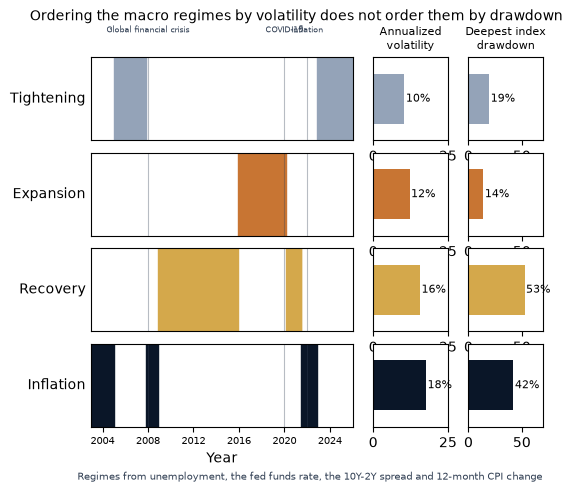

In [26]:
ticks, tick_labels = year_ticks(macro_df.index, every=4)
n_rows = len(regime_order)

fig = plt.figure(figsize=(style.PAGE_WIDTH, 0.85 * n_rows + 1.4))
grid = GridSpec(n_rows, 3, figure=fig, width_ratios=[3.5, 1, 1], wspace=0.15, hspace=0.15)

for i, regime in enumerate(regime_order):
    draw_panel_row(fig, grid, i, regime, first=(i == 0), last=(i == n_rows - 1))

fig.suptitle(
    "Ordering the macro regimes by volatility does not order them by drawdown",
    fontsize=10,
    ha="left",
    x=0.02,
)
fig.text(
    0.5,
    0.0,
    "Regimes from unemployment, the fed funds rate, the 10Y-2Y spread and 12-month CPI change",
    ha="center",
    fontsize=7,
    color=COLORS["neutral"],
)
style.show_with_alt(
    fig,
    "Four stacked timeline rows, one per regime, beside two columns of horizontal bars for "
    "annualized volatility and the deepest index drawdown. The volatility bars grow "
    "steadily down the rows while the drawdown bars do not follow the same order.",
)

### Reading the panel honestly

The volatility ordering is what the panel was sorted on, so it is monotone by
construction and says nothing on its own. The drawdown column is the informative one,
because nothing forced it to agree, and it does not.

### 誠實地解讀這張圖組

波動度的排序正是這張圖組的排序依據,所以它的單調性是建構方式造成的,本身說明不了任何事。回撤那一欄才是有資訊價值的,因為沒有任何東西強迫它要一致,而它確實不一致。

In [27]:
ORDINALS = ["first", "second", "third", "fourth", "fifth", "sixth"]


def rank_by_volatility(regime: str) -> str:
    """Where a regime sits in the volatility ordering the panel is drawn in."""
    return ORDINALS[regime_order.index(regime)]


calmest_regime = str(regime_stats["annual_vol"].idxmin())
loudest_regime = str(regime_stats["annual_vol"].idxmax())
vol_spread = float(regime_stats["annual_vol"].max() - regime_stats["annual_vol"].min())
deepest_month = aligned["drawdown"].idxmin()
deepest_regime = str(aligned.loc[deepest_month, "regime"])
shallowest_regime = str(regime_stats["max_dd_pct"].idxmin())
display(
    Markdown(
        f"Annualized volatility runs from **{calmest_regime}** to **{loudest_regime}**, a "
        f"span of **{vol_spread:.0f} percentage points**. The deepest decline of the whole "
        f"panel, **{regime_stats['max_dd_pct'].max():.0f}%**, falls in "
        f"**{deepest_month:%B %Y}**, which the naming rule calls **{deepest_regime}** - the "
        f"**{rank_by_volatility(deepest_regime)}** of the four by volatility. The shallowest "
        f"decline belongs to **{shallowest_regime}**, the "
        f"**{rank_by_volatility(shallowest_regime)}**."
    )
)

Annualized volatility runs from **Tightening** to **Inflation**, a span of **7 percentage points**. The deepest decline of the whole panel, **53%**, falls in **February 2009**, which the naming rule calls **Recovery** - the **third** of the four by volatility. The shallowest decline belongs to **Expansion**, the **second**.

The volatility ordering is economically legible: a tightening cycle is a calm market with an
expensive policy rate, and the two regimes with an unusual price level or an unusual
unemployment rate are the volatile ones. That is the check passing. Nothing about the
clustering forced it, because the clustering never saw a return.

The drawdown column is where the check bites. It does not follow the volatility order, and
the regime holding the deepest decline is the one the rule names for the aftermath of a
crisis - high unemployment with the policy rate on the floor. That combination is what a
central bank produces in response to a crash, so the label arrives with the crash rather
than before it. The regime a risk report would most want warning of is the one this model
can only confirm.

That is the shape of what macro regimes are for, and it follows from what the inputs are.
Unemployment is measured over a month and published in the next; the policy rate moves in
response to conditions the market has already priced. A label built from them describes the
environment a portfolio is in. Section 1.4 argues for exactly that use - connecting an
identified environment to a predefined risk action - and against reading it as a forecast.

波動度的排序在經濟意義上是讀得通的:緊縮循環是一個政策利率昂貴的平靜市場,而物價水準異常或失業率異常的那兩個市場狀態則是波動劇烈的。這就是檢驗通過的部分。分群過程中沒有任何東西強迫它如此,因為分群從來沒看過任何報酬。

回撤那一欄則是檢驗真正咬人的地方。它並不依循波動度的順序,而包含最深跌幅的市場狀態,正是規則命名為危機餘波的那一個——高失業率加上政策利率貼在下限。這種組合是中央銀行為了因應崩盤而製造出來的,所以這個標籤是隨著崩盤一起到來,而不是在崩盤之前。風險報告最希望能事先得到警告的那個市場狀態,正是這個模型只能事後確認的那一個。

這就是總體經濟市場狀態用途的輪廓,而它是由輸入資料的本質決定的。失業率是對一整個月的衡量,並在下個月才公布;政策利率則是因應市場早已反映在價格上的情勢而變動。由它們建構出來的標籤,描述的是投資組合身處的環境。第 1.4 節主張的正是這種用途——把辨識出來的環境連結到預先定義好的風險行動——並反對把它讀成預測。

### How much of this partition would survive a small change?

Everything above describes one fit. Before any of it is written down, it is worth asking how
much of it is a property of the data and how much is a property of this particular run.

Two perturbations, neither of which changes what the data says. The first refits from a
different random start, which a mixture is entitled to answer differently because
expectation-maximization climbs to a local optimum. The second drops the first few months of
the panel, which is the kind of choice made once and never revisited - a start date is a
judgement about coverage, not a measurement.

Agreement between two partitions is measured by the **adjusted Rand index**: the share of
month pairs that two partitions agree about - either together in both, or separated in both -
rescaled so that a random relabelling scores zero and an identical partition scores one. It
does not care how the clusters are numbered, which is what makes it usable here.

### 這個分割有多少禁得起微小的變動?

以上所有內容描述的都是單一一次配適。在把任何結論寫下來之前,值得先問:其中有多少是資料的性質,又有多少是這一次特定執行的性質。

這裡做兩種擾動,兩者都不改變資料所說的內容。第一種是從不同的隨機起點重新配適,混合模型有權因此給出不同的答案,因為期望最大化演算法只會爬到局部最佳解。第二種是捨棄 panel 最前面的幾個月,這是那種做了一次就再也不會回頭檢視的選擇——起始日期是對資料涵蓋範圍的判斷,而不是一項量測。

兩個分割之間的一致程度以**調整蘭德指數(adjusted Rand index)** 衡量:兩個分割對多少比例的「月份配對」看法一致——在兩者中都同群,或在兩者中都不同群——並重新縮放,使得隨機重新標記得零分、完全相同的分割得一分。它不在乎群集如何編號,這正是它在這裡可用的原因。

In [28]:
def refit(data: np.ndarray, seed: int) -> np.ndarray:
    """Fit the core mixture to *data* from one random start and return its labels."""
    return (
        GaussianMixture(
            n_components=N_REGIMES,
            covariance_type="full",
            random_state=seed,
            n_init=10,
            reg_covar=1e-6,
        )
        .fit(data)
        .predict(data)
    )

In [29]:
perturbations = []
for seed in (0, 7, 123, 2024):
    labels = refit(macro_scaled, seed)
    perturbations.append(
        {
            "Change": f"random start {seed}",
            "Agreement with the fit above": adjusted_rand_score(core_labels, labels),
            "Silhouette": silhouette_score(macro_scaled, labels),
            "Smallest cluster (months)": int(np.bincount(labels).min()),
        }
    )
for dropped in (1, 3, 6, 12):
    labels = refit(macro_scaled[dropped:], SEED)
    perturbations.append(
        {
            "Change": f"drop first {dropped} months",
            "Agreement with the fit above": adjusted_rand_score(core_labels[dropped:], labels),
            "Silhouette": silhouette_score(macro_scaled[dropped:], labels),
            "Smallest cluster (months)": int(np.bincount(labels).min()),
        }
    )
stability = pd.DataFrame(perturbations).set_index("Change")
stability.style.format({"Agreement with the fit above": "{:.2f}", "Silhouette": "{:.3f}"})

,Agreement with the fit above,Silhouette,Smallest cluster (months)
Change,,,
random start 0,1.00,0.327,51
random start 7,0.79,0.320,16
random start 123,0.79,0.320,16
random start 2024,0.81,0.308,20
drop first 1 months,0.79,0.321,16
drop first 3 months,0.73,0.255,4
drop first 6 months,0.82,0.323,20
drop first 12 months,0.77,0.291,4


In [30]:
worst_agreement = float(stability["Agreement with the fit above"].min())
smallest_ever = int(stability["Smallest cluster (months)"].min())
display(
    Markdown(
        f"The least agreement any perturbation reaches is **{worst_agreement:.2f}**, and the "
        f"smallest cluster any of them produces holds **{smallest_ever} months** against "
        f"**{int(np.bincount(core_labels).min())}** in the fit above."
    )
)

The least agreement any perturbation reaches is **0.73**, and the smallest cluster any of them produces holds **4 months** against **51** in the fit above.

None of these partitions is wrong. They are answers to the same question from starts the
data does not distinguish between, and they disagree about a meaningful share of the months.
Some of them split off a cluster small enough that the naming rule reaches a different
branch, so the same panel comes back with a different set of regime names.

The response is not to pick the fit whose names read best. It is to say what was fitted, on
what window, from which start, and to publish the perturbation table beside the result, so
that a reader can see how much of the story is load-bearing. Anything downstream that would
break under an agreement of this size is not supported by this model, whatever the figure
looks like.

This is the chapter's argument arriving in one table. The model is ordinary and takes four
lines to fit; what separates a usable result from an anecdote is the check that comes after
it, and the discipline to report the check when it is unflattering.

這些分割沒有一個是錯的。它們是從資料無法區分優劣的不同起點出發,對同一個問題給出的答案,而且它們對相當可觀比例的月份意見不一。其中有些分出了一個小到讓命名規則走到不同分支的群集,所以同一個 panel 會回傳一組不同的市場狀態名稱。

因應之道不是挑選名稱讀起來最順的那次配適。而是說明配適了什麼、用哪個視窗、從哪個起點,並把擾動表和結果一併發表,讓讀者看得出這個故事有多少是真正承重的。任何會在這種程度的一致性之下崩解的下游應用,都得不到這個模型的支持,不論圖看起來如何。

這就是本章的論點濃縮在一張表裡。模型很普通,四行程式碼就能配適;區分可用的結果與軼事的,是配適之後的檢驗,以及在檢驗結果不好看時仍然如實報告的紀律。

### Figure 1.6 inputs

The print version of Figure 1.6 is drawn by
`book/01_process_is_edge/figures/scripts/generate_figure_1_6_macro_regimes_volatility.py`
in the book repository, which reads the arrays written below rather than re-fitting the
clustering.

### 圖 1.6 的輸入資料

圖 1.6 的印刷版本是由書籍儲存庫中的
`book/01_process_is_edge/figures/scripts/generate_figure_1_6_macro_regimes_volatility.py`
繪製的,它會讀取下面寫出的陣列,而不是重新配適分群。

In [31]:
ARTIFACT_DIR = OUTPUT_DIR / "figure_1_6"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.savez(
    ARTIFACT_DIR / "inputs.npz",
    dates=macro_df.index.astype("datetime64[ns]").astype("int64"),
    macro_labels=np.asarray(core_labels, dtype=np.int64),
    regime_order=np.asarray(regime_order, dtype=object),
    raw_regime_for_order=np.asarray(
        [next(c for c, name in cluster_names.items() if name == regime) for regime in regime_order],
        dtype=np.int64,
    ),
    annual_vol=regime_stats.loc[regime_order, "annual_vol"].to_numpy(dtype=float),
    max_dd_pct=regime_stats.loc[regime_order, "max_dd_pct"].to_numpy(dtype=float),
    event_years=np.asarray(list(EVENTS), dtype=np.int64),
    event_labels=np.asarray(list(EVENTS.values()), dtype=object),
    start_year=np.int64(PANEL_FIRST_YEAR),
    end_year=np.int64(PANEL_LAST_YEAR),
)

## How the four indicators move together

A clustering on four correlated inputs is not a clustering in four independent
directions, so the correlations are worth seeing before the extended panel raises the
question at a larger scale. Only one triangle is drawn: the matrix is symmetric and the
other half carries no additional information. The scale is fixed to the full range a
correlation can take, so the colours mean the same thing here as in any other correlation
figure in the book.

## 四個指標如何一起變動

對四個彼此相關的輸入做分群,並不是在四個獨立方向上做分群,所以在擴充 panel 把這個問題放大之前,值得先看看相關性。圖中只畫出一個三角:矩陣是對稱的,另一半不帶任何額外資訊。色階固定在相關係數可能取值的完整範圍,所以這裡的顏色與書中其他任何相關性圖表中的意義相同。

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


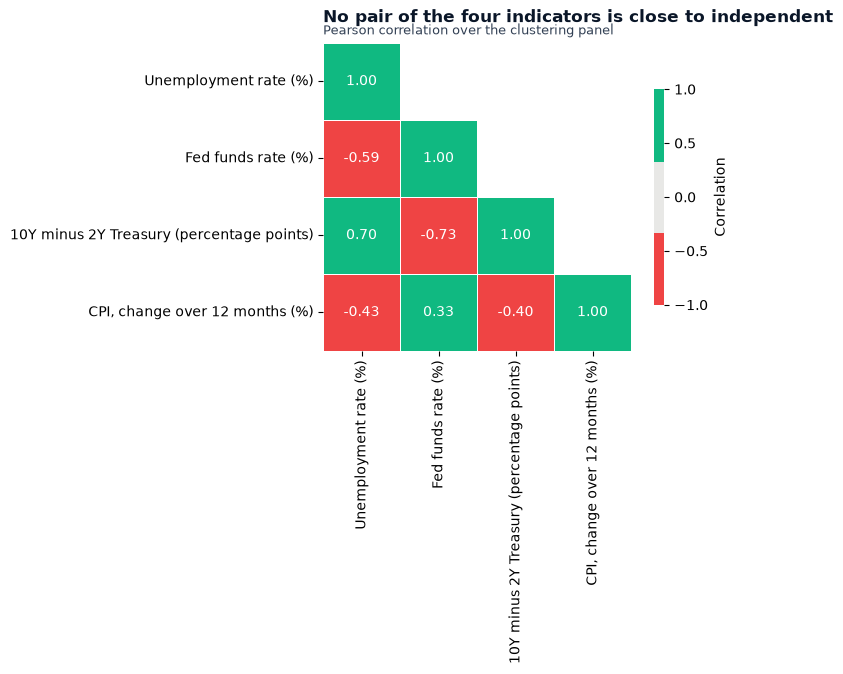

In [32]:
correlations = macro_df.rename(columns=UNITS).corr()

fig, ax = plt.subplots(figsize=style.FIGSIZE["single_tall"])
sns.heatmap(
    correlations,
    mask=style.upper_triangle_mask(correlations),
    annot=True,
    fmt=".2f",
    cmap=style.ml4t_diverging(),
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlation"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
style.add_message_title(
    ax,
    "No pair of the four indicators is close to independent",
    subtitle="Pearson correlation over the clustering panel",
)
style.show_with_alt(
    fig,
    "A lower-triangular correlation heatmap of four macro indicators on a red-to-blue scale "
    "fixed between minus one and one. The unemployment rate and the yield spread are "
    "strongly positive, the fed funds rate is strongly negative against the yield spread, "
    "and inflation is moderately negative against unemployment.",
)

Unemployment and the yield spread move together, and the fed funds rate moves against the
spread. Both are the same mechanism seen from two sides: the Federal Reserve cuts the
short rate when the labour market weakens, which pulls the front of the curve down and
steepens the spread, and it raises the short rate when the economy runs hot, which flattens
or inverts it. Inflation is the least entangled of the four and is still not independent of
them.

That is the case for clustering jointly rather than thresholding one series at a time. Any
single indicator tells the same story as its neighbours plus its own noise; the joint model
reads all four positions at once, which is how it can separate the tightening cycle from
the recovery even though both involve an unusual short rate.

失業率與殖利率利差同向變動,聯邦基金利率則與利差反向變動。兩者是同一個機制的一體兩面:勞動市場轉弱時,聯準會調降短期利率,把曲線前端往下拉,使利差變陡;經濟過熱時,它調升短期利率,使曲線變平或倒掛。通膨是四者中糾纏最少的,但仍然不是獨立於其他三者。

這就是要聯合分群、而不是一次對一個序列設門檻的理由。任何單一指標講的都是和它鄰居相同的故事,再加上它自己的雜訊;聯合模型一次讀取四個位置,所以即使緊縮循環與復甦期都涉及不尋常的短期利率,它仍然能把兩者區分開來。

## The counter-experiment: every series in the panel

The core model uses four series chosen for what they mean. The obvious question is whether
adding the rest of the file would do better, and the obvious way to answer it is to fit the
same mixture to everything and compare the separation scores.

That comparison is the trap this section exists to spring. The extended panel is assembled
with no judgement at all beyond a coverage filter, which is exactly how such a panel is
usually built.

## 對照實驗:panel 中的每一個序列

核心模型使用的是依其意義挑選出來的四個序列。顯而易見的問題是:把檔案裡其餘的序列都加進來會不會更好?而顯而易見的回答方式,是把同一個混合模型配適到全部資料上,然後比較分離度分數。

這個比較正是本節要引人踩進去的陷阱。擴充 panel 的組成方式除了一道資料涵蓋率的過濾條件之外,完全不加任何判斷,而這類 panel 通常就是這樣建出來的。

In [33]:
value_columns = [c for c in macro_raw.columns if c != DATE_COL]
monthly_full = to_monthly(macro_raw, value_columns).filter(pl.col(DATE_COL) >= PANEL_START)

missing_share = {
    column: monthly_full.select(pl.col(column).is_null().sum()).item() / monthly_full.height
    for column in value_columns
}
kept_columns = [c for c, share in missing_share.items() if share <= MAX_MISSING_SHARE]

extended_pl = monthly_full.select([DATE_COL, *kept_columns]).drop_nulls()
extended_df = extended_pl.select(kept_columns).to_pandas()
extended_df.index = pd.DatetimeIndex(extended_pl[DATE_COL].to_pandas())

# Hold both models to the same months. Left alone the two panels start a month apart - the
# core one waits twelve months for the year-over-year change, this one waits for the Fed
# balance sheet to begin - and every comparison below would then be partly about the window.
extended_df = extended_df.loc[extended_df.index.intersection(macro_df.index)].apply(scale)
if not extended_df.index.equals(macro_df.index):
    raise ValueError("The extended panel does not cover the same months as the core panel")

display(
    Markdown(
        f"The coverage filter keeps **{len(kept_columns)} of {len(value_columns)}** series, "
        f"and holding them to the core panel's months leaves **{len(extended_df)} months** "
        "across both models."
    )
)

The coverage filter keeps **25 of 25** series, and holding them to the core panel's months leaves **276 months** across both models.

### What the filter let through

Nothing in that assembly asked what the columns are, and the metadata table at the top of the
notebook says what got in: Treasury yields at maturities from one to thirty years, which move
almost as one series; a derived column whose formula is the ten-year yield minus the two-year,
which is the definition of a series already in the panel under its own name; nominal and real
GDP, published quarterly, so each repeats a value for three months at a time; and three price
indices entering as levels, which is the treatment the core panel rejected for one of them.

Two of those are checkable without reading the metadata at all. Columns holding the same
series differ by nothing anywhere in the panel, and a series published quarterly and carried
forward to a monthly grid is unchanged from the previous month in two months out of three.

### 過濾條件放了什麼進來

那段組裝過程完全沒有問過這些欄位是什麼,而筆記本開頭的中繼資料表說明了進來的是什麼:一年期到三十年期各天期的公債殖利率,它們幾乎像同一個序列一樣變動;一個衍生欄位,其公式是十年期殖利率減去兩年期殖利率,而這正是 panel 中已經以自己名稱存在的某個序列的定義;名目與實質 GDP,每季發布一次,所以每個數值都會連續重複三個月;以及三個以水準值進入的物價指數,而這正是核心 panel 對其中一個指數所拒絕採用的處理方式。

其中兩項完全不必讀中繼資料就能檢查。存放同一個序列的欄位,在 panel 中任何地方的差異都是零;而每季發布、再向前延續到月頻格點上的序列,每三個月中就有兩個月與前一個月相同。

In [34]:
def duplicate_pairs(frame: pd.DataFrame, tolerance: float = 1e-9) -> list[tuple[str, str]]:
    """Column pairs that hold the same standardized series to within *tolerance*."""
    columns = list(frame.columns)
    return [
        (a, b)
        for i, a in enumerate(columns)
        for b in columns[i + 1 :]
        if float((frame[a] - frame[b]).abs().max()) < tolerance
    ]

In [35]:
duplicates = duplicate_pairs(extended_df)
carried_forward = (extended_df.diff() == 0).mean().sort_values(ascending=False)
stalest = str(carried_forward.index[0])
display(
    Markdown(
        f"Comparing every pair of columns finds **{len(duplicates)}** holding the same "
        f"standardized series: {', '.join(f'`{a}` and `{b}`' for a, b in duplicates) or 'none'}. "
        f"The column that repeats itself most is `{stalest}`, unchanged from the month before "
        f"in **{carried_forward.iloc[0]:.0%}** of the panel."
    )
)

Comparing every pair of columns finds **1** holding the same standardized series: `t10y2y` and `YIELD_CURVE_SLOPE`. The column that repeats itself most is `gdpc1`, unchanged from the month before in **67%** of the panel.

### The series, drawn

Every kept column standardized and plotted on shared axes. The point of the small multiples
is the shape of each panel, not its level: how many of them are the same line.

### 把序列畫出來

每個被保留的欄位經過標準化後,畫在共用的座標軸上。這些小圖(small multiples)的重點是每一格的形狀,而不是水準:其中有多少格根本是同一條線。

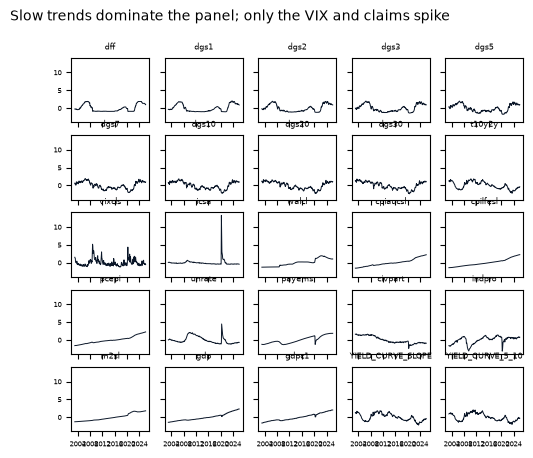

In [36]:
n_columns = 5
n_rows_grid = int(np.ceil(len(extended_df.columns) / n_columns))
fig, axes = plt.subplots(
    n_rows_grid,
    n_columns,
    figsize=(style.PAGE_WIDTH, 0.85 * n_rows_grid + 0.6),
    sharex=True,
    sharey=True,
)
for ax, column in zip(axes.flat, extended_df.columns):
    ax.plot(extended_df.index, extended_df[column], color=COLORS["blue"], linewidth=0.7)
    ax.set_title(column, fontsize=6)
    ax.tick_params(labelsize=5)
for ax in axes.flat[len(extended_df.columns) :]:
    ax.set_visible(False)

fig.suptitle(
    "Slow trends dominate the panel; only the VIX and claims spike",
    fontsize=10,
    ha="left",
    x=0.02,
)
style.show_with_alt(
    fig,
    "A grid of small standardized time-series panels sharing their axes. Several rise "
    "steadily from one end of the window to the other, the Treasury yields move together "
    "in broad waves, and only the VIX and initial jobless claims show sharp isolated "
    "spikes against an otherwise flat line.",
)

### How much independent variation is left

Principal component analysis puts a number on the redundancy the figure shows. Each
component is the direction of greatest remaining variance, and the cumulative share says
how much of the panel's total variation the first few directions account for.

### 還剩下多少獨立的變異

主成分分析(principal component analysis)為圖中顯示的冗餘程度給出一個數字。每個主成分是剩餘變異最大的方向,而累積比例則說明前幾個方向解釋了 panel 總變異的多少。

In [37]:
pca = PCA(n_components=min(10, extended_df.shape[1]))
reduced = pca.fit_transform(extended_df)

explained = pd.DataFrame(
    {
        "Component": [f"PC{i + 1}" for i in range(pca.n_components_)],
        "Share of variance": pca.explained_variance_ratio_,
        "Cumulative": np.cumsum(pca.explained_variance_ratio_),
    }
).set_index("Component")
explained.style.format("{:.1%}")

,Share of variance,Cumulative
Component,,
PC1,45.6%,45.6%
PC2,34.8%,80.3%
PC3,7.5%,87.9%
PC4,5.8%,93.6%
PC5,2.4%,96.0%
PC6,1.8%,97.8%
PC7,1.0%,98.8%
PC8,0.6%,99.4%
PC9,0.2%,99.7%


In [38]:
two_component_share = float(explained["Cumulative"].iloc[1])
display(
    Markdown(
        f"Two directions account for **{two_component_share:.0%}** of the variance across "
        f"**{extended_df.shape[1]} columns**."
    )
)

Two directions account for **80%** of the variance across **25 columns**.

### Which columns each direction is made of

The share of variance says how much a direction carries; the loadings say what it is. Each
column below lists the four series with the largest absolute weight in that component,
heaviest first.

### 每個方向是由哪些欄位組成的

變異比例說明一個方向承載了多少;負荷量(loadings)則說明它是什麼。下面每一欄列出在該主成分中絕對權重最大的四個序列,由重到輕排列。

In [39]:
loadings = pd.DataFrame(pca.components_.T, index=extended_df.columns, columns=explained.index)
pd.DataFrame(
    {
        component: loadings[component].abs().sort_values(ascending=False).index[:4].tolist()
        for component in explained.index[:4]
    },
    index=[f"Heaviest {i + 1}" for i in range(4)],
)

,PC1,PC2,PC3,PC4
Heaviest 1,payems,dgs10,indpro,icsa
Heaviest 2,gdp,dgs20,vixcls,vixcls
Heaviest 3,YIELD_CURVE_SLOPE,dgs7,unrate,t10y2y
Heaviest 4,t10y2y,dgs30,dgs20,YIELD_CURVE_SLOPE


The leading direction is the trend the small multiples showed, and the second is the level
of the long end of the Treasury curve. Neither is a regime. The series that move when
conditions break - the VIX, initial jobless claims - do not appear until the third and
fourth components, which between them carry a small share of the variance. A mixture fitted
on this panel is therefore fitted mostly on where in the sample a month sits, which is what
the episode count is about to show.

第一個方向就是小圖所顯示的趨勢,第二個則是公債殖利率曲線長端的水準。兩者都不是市場狀態。在情勢急轉直下時會變動的序列——VIX、初領失業救濟金人數——要到第三與第四主成分才出現,而這兩個主成分合計只承載了一小部分的變異。因此,在這個 panel 上配適的混合模型,主要是依據某個月位於樣本中的哪個位置來配適的,而這正是區段數即將顯示的。

## Fit the same models to the extended panel

A mixture and a k-means partition, both at the same cluster count as the core model, plus a
mixture on the ten leading principal components to see whether reducing the redundancy
changes the answer.

## 將同樣的模型配適到擴充 panel

一個混合模型與一個 k-means 分割,兩者的群集數都與核心模型相同;另外再加上一個配適在前十個主成分上的混合模型,看看降低冗餘是否會改變答案。

In [40]:
gmm_extended = GaussianMixture(
    n_components=N_REGIMES, covariance_type="full", random_state=SEED, n_init=10, reg_covar=1e-6
).fit(extended_df)
extended_labels = gmm_extended.predict(extended_df)
extended_probabilities = gmm_extended.predict_proba(extended_df)

kmeans_labels = KMeans(n_clusters=N_REGIMES, random_state=SEED, n_init=10).fit_predict(extended_df)

gmm_pca = GaussianMixture(
    n_components=N_REGIMES, covariance_type="full", random_state=SEED, n_init=10, reg_covar=1e-6
).fit(reduced)
pca_labels = gmm_pca.predict(reduced)

comparison = pd.DataFrame(
    {
        "Model": [
            f"Core, {len(CORE_SERIES)} chosen series",
            f"Extended, {extended_df.shape[1]} series",
            "Extended, 10 principal components",
            f"Extended, {extended_df.shape[1]} series, k-means",
        ],
        "Silhouette": [
            core_silhouette,
            silhouette_score(extended_df, extended_labels),
            silhouette_score(reduced, pca_labels),
            silhouette_score(extended_df, kmeans_labels),
        ],
    }
).set_index("Model")
comparison.style.format("{:.3f}")

,Silhouette
Model,
"Core, 4 chosen series",0.327
"Extended, 25 series",0.419
"Extended, 10 principal components",0.397
"Extended, 25 series, k-means",0.448


### The score says the extended panel is better. Look at what it bought.

An **episode** is a maximal run of consecutive months carrying the same label. Counting
them separates a model that recovers recurring conditions from one that has cut the sample
into consecutive blocks: a condition that recurs produces many episodes and revisits
earlier labels, while a chronological cut produces exactly as many episodes as it has
clusters and never returns to one.

### 分數說擴充 panel 比較好。看看它買到了什麼。

所謂**區段(episode)**,是指帶有相同標籤的連續月份所構成的最長連續期間。計算區段數,可以把「還原出反覆出現之情勢的模型」與「只是把樣本切成連續區塊的模型」區分開來:會反覆出現的情勢會產生很多區段,並且重新回到先前的標籤;而依時間順序的切割所產生的區段數恰好等於群集數,而且永遠不會回到任何一個。

In [41]:
def episode_count(labels: np.ndarray) -> int:
    """Number of maximal runs of consecutive months sharing a label."""
    return int(np.sum(np.diff(labels) != 0)) + 1


def revisited_clusters(labels: np.ndarray) -> int:
    """How many clusters the model returns to after having left them."""
    starts = [labels[0], *labels[1:][np.diff(labels) != 0]]
    return sum(1 for cluster in set(starts) if starts.count(cluster) > 1)


episodes = pd.DataFrame(
    {
        "Model": [
            f"Core, {len(CORE_SERIES)} chosen series",
            f"Extended, {extended_df.shape[1]} series",
        ],
        "Clusters": [N_REGIMES, N_REGIMES],
        "Episodes": [episode_count(core_labels), episode_count(extended_labels)],
        "Clusters revisited": [
            revisited_clusters(core_labels),
            revisited_clusters(extended_labels),
        ],
    }
).set_index("Model")
episodes

,Clusters,Episodes,Clusters revisited
Model,,,
"Core, 4 chosen series",4,8,3
"Extended, 25 series",4,4,0


In [42]:
extended_episodes = episode_count(extended_labels)
core_episodes = episode_count(core_labels)
display(
    Markdown(
        f"The extended model splits {len(extended_df)} months into **{extended_episodes} "
        f"episodes** from **{N_REGIMES} clusters**, returning to "
        f"**{revisited_clusters(extended_labels)}** of them, against "
        f"**{core_episodes} episodes** and "
        f"**{revisited_clusters(core_labels)}** revisited for the core model."
    )
)

The extended model splits 276 months into **4 episodes** from **4 clusters**, returning to **0** of them, against **8 episodes** and **3** revisited for the core model.

A model with as many episodes as clusters and none of them revisited has assigned every
month to the cluster of its neighbours and never returned to a condition it had left. It has
partitioned the calendar into consecutive eras. The core model does return, which is what
lets it call the 2008 aftermath and the 2020 aftermath the same thing. That is what the trending levels put into the panel - three
price indices, two GDP series, money stock, payrolls - and it is precisely the failure the
core panel avoided by taking a rate of change instead of a level. The silhouette score
rewards it, because consecutive eras of a trending panel are far apart in the space the
score measures distance in.

The lesson generalises past this dataset. A separation score answers "are these groups far
apart", and a regime model has to answer "would this label have told me something the next
time conditions like these arrived". Nothing forces those two questions to have the same
answer, and a panel assembled without judgement is where they come apart.

一個區段數與群集數相同、而且沒有任何一個被重新造訪的模型,是把每個月都指派到它鄰近月份的群集,並且從未回到它離開過的情勢。它把日曆分割成了連續的時代。核心模型則會回去,正因如此,它才能把 2008 年的餘波與 2020 年的餘波稱為同一件事。這就是帶趨勢的水準值——三個物價指數、兩個 GDP 序列、貨幣存量、就業人數——給 panel 帶來的東西,而這恰恰是核心 panel 藉由採用變動率而非水準值所避開的失敗。輪廓係數會獎勵這種結果,因為在該分數用來衡量距離的空間裡,一個帶趨勢 panel 的各個連續時代彼此相距很遠。

這個教訓可以推廣到這個資料集之外。分離度分數回答的是「這些群組彼此離得遠嗎」,而市場狀態模型必須回答的是「下次類似的情勢出現時,這個標籤會告訴我什麼有用的事嗎」。沒有任何東西強迫這兩個問題有相同的答案,而一個不加判斷組裝起來的 panel,正是它們分道揚鑣的地方。

### The two partitions, drawn

Assignment probabilities from both mixtures over the same months. Darker means the model
was more confident the month belonged to that cluster.

### 把兩個分割畫出來

兩個混合模型在相同月份上的指派機率。顏色越深,表示模型越有把握該月份屬於那個群集。

In [43]:
def plot_assignment_heatmap(probabilities: np.ndarray, dates: pd.DatetimeIndex, claim: str) -> None:
    """Draw per-month cluster assignment probabilities as a heatmap."""
    fig, ax = plt.subplots(figsize=style.FIGSIZE["single_wide"])
    image = ax.imshow(probabilities.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    positions, labels = year_ticks(dates, every=4)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_yticks(range(probabilities.shape[1]))
    ax.set_yticklabels([f"Cluster {i}" for i in range(probabilities.shape[1])])
    ax.set_xlabel("Year")
    fig.colorbar(image, ax=ax, shrink=0.8, label="Assignment probability")
    style.add_message_title(ax, claim)
    style.show_with_alt(
        fig,
        "A heatmap with one row per cluster and one column per month, shaded by assignment "
        "probability.",
    )

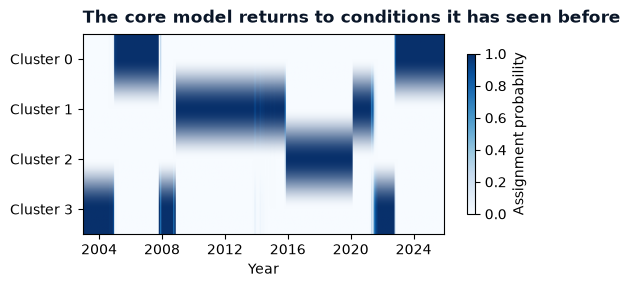

In [44]:
plot_assignment_heatmap(
    core_probabilities, macro_df.index, "The core model returns to conditions it has seen before"
)

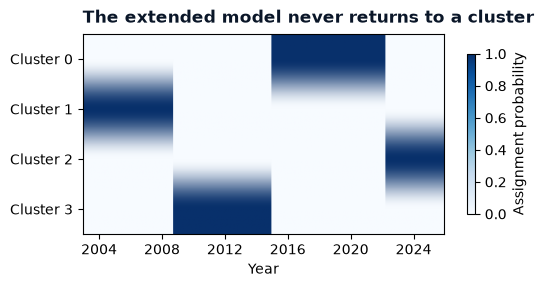

In [45]:
plot_assignment_heatmap(
    extended_probabilities, extended_df.index, "The extended model never returns to a cluster"
)

## Clustering the indicators rather than the months

Everything so far has grouped months. The same machinery can group the columns instead,
which answers a different question: which indicators carry the same information? Ward
linkage builds a tree by repeatedly merging the two groups whose merger adds least to the
within-group variance.

The **cophenetic correlation** measures how well such a tree preserves the distances it was
built from. For each pair of items it reads the height at which the tree first joins them,
and correlates those heights against the original pairwise distances. A tree that scores
near one is a faithful summary of the distance matrix; one that scores low has imposed a
hierarchy the data does not have.

Two trees are built below and they answer different questions, so their cophenetic
correlations are not interchangeable. The first is over the columns and is what the block
structure in the figure refers to. The second is over the months.

## 對指標分群,而不是對月份分群

到目前為止,所有的分群對象都是月份。同一套機制也可以改為對欄位分群,這回答的是另一個問題:哪些指標帶有相同的資訊?Ward 連結法(Ward linkage)建立樹的方式,是反覆合併「合併後群內變異增加最少」的兩個群組。

**共表相關係數(cophenetic correlation)** 衡量這樣一棵樹在多大程度上保留了建構它時所用的距離。對每一對項目,它讀取樹首次把它們連接起來的高度,再把這些高度與原始的兩兩距離計算相關。分數接近一的樹是距離矩陣的忠實摘要;分數低的樹則是強加了一個資料本身沒有的階層結構。

下面建了兩棵樹,它們回答的是不同的問題,所以它們的共表相關係數不能互換使用。第一棵是對欄位建的,也就是圖中區塊結構所指的那一棵。第二棵則是對月份建的。

In [46]:
column_distances = pdist(extended_df.T)
column_linkage = linkage(column_distances, method="ward")
column_cophenetic, _ = cophenet(column_linkage, column_distances)

month_distances = pdist(extended_df)
month_linkage = linkage(month_distances, method="ward")
month_cophenetic, _ = cophenet(month_linkage, month_distances)

display(
    Markdown(
        f"Cophenetic correlation is **{column_cophenetic:.2f}** for the tree over the "
        f"indicators and **{month_cophenetic:.2f}** for the tree over the months, against a "
        f"conventional bar of {MIN_COPHENETIC}."
    )
)

Cophenetic correlation is **0.89** for the tree over the indicators and **0.71** for the tree over the months, against a conventional bar of 0.7.

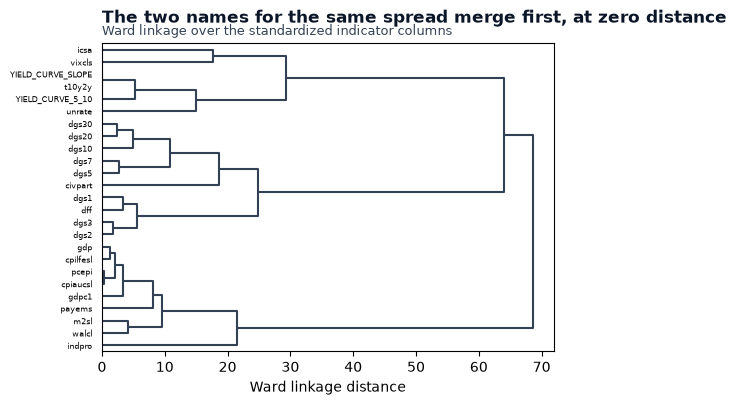

In [47]:
fig, ax = plt.subplots(figsize=style.FIGSIZE["single_tall"])
dendrogram(
    column_linkage,
    labels=extended_df.columns.tolist(),
    orientation="right",
    ax=ax,
    color_threshold=0,
    link_color_func=lambda _: COLORS["neutral"],
)
ax.set_xlabel("Ward linkage distance")
ax.tick_params(axis="y", labelsize=6)
style.add_message_title(
    ax,
    "The two names for the same spread merge first, at zero distance",
    subtitle="Ward linkage over the standardized indicator columns",
)
style.show_with_alt(
    fig,
    "A horizontal dendrogram of the panel's columns. One pair joins at the left edge with "
    "no visible branch length; the Treasury maturities and the trending level series form "
    "two further groups, and the VIX and initial claims stand apart until the last merge.",
)

In [48]:
first_merge_distance = float(column_linkage[0, 2])
merged_first = [extended_df.columns[int(i)] for i in column_linkage[0, :2]]
display(
    Markdown(
        f"The first merge the tree makes is `{merged_first[0]}` with `{merged_first[1]}`, at "
        f"a distance of **{first_merge_distance:.1e}**."
    )
)

The first merge the tree makes is `t10y2y` with `YIELD_CURVE_SLOPE`, at a distance of **4.0e-15**.

A merge at zero distance is two copies of one column, and the tree finds it before it
considers anything else. Above that the panel resolves into groups a reader can name: the
series that only trend, the short and medium Treasury yields, the curve-shape series
alongside unemployment, and - joining last, at the greatest distance - the VIX and initial
jobless claims. That last pair is the only part of the panel that moves on the timescale a
crisis moves on, which is why the principal components leave it until third and fourth
place while spending the first two on trend and on the level of long rates.

What the tree does not do is choose the panel. It says which columns duplicate each other;
which of a duplicated pair to keep is decided on grounds the data cannot supply - what the
column means, and whether it is published in time to be read when a decision has to be
made.

在距離為零處的合併,是同一個欄位的兩份複本,而樹在考慮其他任何東西之前就先找到了它。在那之上,panel 分解成讀者叫得出名字的幾個群組:只有趨勢的序列、短期與中期公債殖利率、曲線形狀的序列連同失業率,以及——最後才加入、距離也最遠的——VIX 與初領失業救濟金人數。最後這一對是 panel 中唯一以危機發展的時間尺度在變動的部分,這就是為什麼主成分把前兩名花在趨勢與長期利率的水準上,而把它留到第三與第四名。

這棵樹沒有做的事,是替我們選定 panel。它說明了哪些欄位彼此重複;但在一對重複的欄位中該保留哪一個,則是依據資料無法提供的理由來決定的——這個欄位的意義是什麼,以及它是否發布得夠及時,能在必須做決策的時候被讀到。

## Key takeaways

- **Level or rate is the first decision, not a preprocessing detail.** A trending column
  entering a clustering makes elapsed time the dominant direction of variance, and the
  partition that comes back is a partition of the calendar wearing economic names.
- **A separation score is not a validation.** Silhouette answers whether the groups are far
  apart in the space they were fitted in. Whether the groups mean anything is a separate
  question, and counting episodes - does the model ever return to a cluster? - is a cheap
  way to ask it.
- **More series is not more information.** Nine Treasury maturities, a spread stored twice,
  and two GDP measures are one panel with a few directions in it, which principal components
  and the linkage tree both report directly.
- **Attaching names to clusters is an assertion.** The mixture supplies a partition; every
  economic name here comes from a threshold rule written by hand, and a different rule would
  rename the same partition.
- **Validate a regime model against something it never saw.** These regimes were fitted
  without any market data, so equity volatility and drawdown are an independent check. Half
  of it passed - the volatility ordering is economically legible - and half of it did not:
  the deepest drawdown sits in the regime named for a crisis already under way.
- **Perturb the fit before you write about it.** A different random start, or a sample three
  months shorter, moves this partition enough to change which names the rule assigns. Report
  that alongside the result; a story the perturbation table takes apart was never supported
  by the data.

**Known limitations.** FRED serves revised values, so no number here was available on the
date it is attached to. The mixture has no transition structure and no notion of time, so
nothing prefers a month to keep its neighbour's label; the long episodes here come from the
indicators moving slowly, not from the model. The panel starts in 2002 and holds one severe
recession, one pandemic and one inflation episode, which is too few repetitions of any
condition to say how often it recurs - and it is the direct cause of the instability the
perturbation table reports. The naming rule's thresholds were set for the post-2002 US
economy and would not transfer to another country or another era.

**Next**: Chapter 1 closes on what a research process needs to survive changes like these.
Walk-forward estimation, which is what turns a descriptive regime label into one a strategy
could act on, is introduced from Chapter 6.

## 重點整理

- **用水準值還是變動率是第一項決策,不是前處理的細節。** 一個帶趨勢的欄位進入分群後,會讓經過的時間成為變異的主導方向,而得到的分割只是披著經濟名稱的日曆分割。
- **分離度分數不是驗證。** 輪廓係數回答的是這些群組在它們被配適的空間裡是否離得很遠。這些群組是否有任何意義則是另一個問題,而計算區段數——模型是否曾經回到某個群集?——是提出這個問題的便宜方法。
- **更多序列不等於更多資訊。** 九個公債天期、一個被存了兩次的利差,以及兩種 GDP 衡量方式,合起來只是一個裡面僅有少數幾個方向的 panel,主成分與連結樹都直接指出了這一點。
- **為群集冠上名稱是一種主張。** 混合模型提供的是一個分割;這裡的每個經濟名稱都來自手寫的門檻規則,而換一條規則就會為同一個分割重新命名。
- **用模型從未看過的東西來驗證市場狀態模型。** 這些市場狀態是在沒有任何市場資料的情況下配適的,所以股票波動度與回撤是獨立的檢驗。它有一半通過了——波動度的排序在經濟意義上讀得通——另一半則沒有:最深的回撤落在以「已經在進行中的危機」命名的那個狀態裡。
- **在動筆寫之前先擾動配適結果。** 換一個隨機起點,或把樣本縮短三個月,就足以讓這個分割變動到改變規則所指派的名稱。請把這一點和結果一併報告;一個會被擾動表拆穿的故事,從來就沒有得到資料的支持。

**已知限制。** FRED 提供的是修訂後的數值,所以這裡沒有任何一個數字在它所標示的日期當時是可取得的。混合模型沒有轉移結構,也沒有時間的概念,所以沒有任何東西偏好讓某個月沿用鄰近月份的標籤;這裡的長區段來自指標本身變動緩慢,而不是來自模型。panel 從 2002 年開始,只包含一次嚴重衰退、一次疫情與一次通膨事件,任何一種情勢的重複次數都太少,無法說明它多常重現——而這正是擾動表所呈現之不穩定性的直接原因。命名規則的門檻是針對 2002 年之後的美國經濟設定的,無法移植到其他國家或其他時代。

**接下來**:第 1 章以「一套研究流程需要什麼才能撐過這類變化」作結。前推式(walk-forward)估計能把描述性的市場狀態標籤轉變成策略可以據以行動的標籤,將從第 6 章開始介紹。